# MinHash-based Document Similarity Analysis

This notebook implements MinHash algorithm to find similar documents using 3-grams and Jaccard similarity estimation.

In [201]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import random
import seaborn as sns
from typing import List, Set, Tuple
import hashlib
import re

random.seed(42)

## Sample Text Documents

In [202]:
documents = [
    "NASA plans to build a Mars base by 2040 with ESA through joint space missions.",
    "Farmers are adapting to climate change by using sustainable agricultural methods.",
    "Apple and Microsoft reported strong Q1 earnings, boosting tech stock prices today.",
    "Sustainable agricultural methods are helping farmers adapt to climate change impacts.",
    "Apple and Microsoft earnings for Q1 were strong, leading to a surge in tech stocks.",
    "ESA and NASA will collaborate on Mars base construction by 2040 through joint efforts.",
    "Tech stocks surged today after strong earnings reports from Apple and Microsoft.",
    "Climate change is pushing farmers to use sustainable methods in agriculture.",
    "By 2040, NASA and ESA plan to construct a base on Mars via joint mission efforts.",
    "Strong Q1 earnings from Apple and Microsoft resulted in a boost for tech stocks.",
    "Farmers are turning to sustainable agriculture to counter the effects of climate change.",
    "Joint space missions between NASA and ESA will establish a Mars base by 2040.",
    "Microsoft and Apple both saw strong Q1 earnings, sending tech stocks higher today.",
    "NASA plans to build a Mars base by 2040 with ESA through space missions.",
    "A Mars base will be built by NASA and ESA by 2040 through joint space collaboration.",
    "Sustainable agriculture is the response farmers are taking to climate change.",
    "Tech stocks are up as Apple and Microsoft posted strong Q1 earnings results.",
    "NASA and ESA will jointly construct a Mars base by 2040 as part of global space efforts.",
    "Adapting to climate change, farmers are using sustainable agriculture techniques.",
    "Apple and Microsoft’s strong earnings boosted tech markets significantly today."
]


print(f"Created {len(documents)} sample documents")
print("\nFirst 3 documents:")
for i, doc in enumerate(documents[:3]):
    print(f"Doc {i+1}: {doc}")

Created 20 sample documents

First 3 documents:
Doc 1: NASA plans to build a Mars base by 2040 with ESA through joint space missions.
Doc 2: Farmers are adapting to climate change by using sustainable agricultural methods.
Doc 3: Apple and Microsoft reported strong Q1 earnings, boosting tech stock prices today.


## 3-grams Generation for Each Document

In [203]:
def preprocess(text: str) -> str:
    text = text.lower()
    text = re.sub(r'\W+', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def generate_kgrams(text: str, k: int = 1) -> Set[str]:
    text = preprocess(text)
    words = text.split()
    return set([" ".join(words[i:i+k]) for i in range(len(words)-(k - 1))])

# Generate 3-grams for all documents
document_shingles = []
for i, doc in enumerate(documents):
    shingles = generate_kgrams(doc)
    document_shingles.append(shingles)
    print(f"Document {i+1}: {len(shingles)} 3-grams")

print(f"\nExample 3-grams from Document 1: {list(document_shingles[0])[:10]}")

Document 1: 15 3-grams
Document 2: 11 3-grams
Document 3: 12 3-grams
Document 4: 11 3-grams
Document 5: 15 3-grams
Document 6: 14 3-grams
Document 7: 12 3-grams
Document 8: 11 3-grams
Document 9: 16 3-grams
Document 10: 14 3-grams
Document 11: 12 3-grams
Document 12: 14 3-grams
Document 13: 13 3-grams
Document 14: 14 3-grams
Document 15: 15 3-grams
Document 16: 11 3-grams
Document 17: 13 3-grams
Document 18: 17 3-grams
Document 19: 10 3-grams
Document 20: 11 3-grams

Example 3-grams from Document 1: ['to', 'with', 'missions', 'build', 'nasa', 'by', 'plans', 'esa', 'through', 'joint']


## MinHash Implementation with 50+ Hash Functions

In [204]:
class MinHashSignature:
    def __init__(self, num_hashes: int = 100):
        self.num_hashes = num_hashes
        self.hash_functions = self._generate_hash_functions()
    
    def _generate_hash_functions(self) -> List[Tuple[int, int]]:
        # Large prime number
        p = 2**31 - 1
        hash_funcs = []
        
        for i in range(self.num_hashes):
            # Random coefficients for each hash function
            a = random.randint(1, p-1)
            b = random.randint(0, p-1)
            hash_funcs.append((a, b, p))
        
        return hash_funcs
    
    def _hash_shingle(self, shingle: str, hash_func: Tuple[int, int, int]) -> int:
        a, b, p = hash_func
        x = int(hashlib.md5(shingle.encode('utf-8')).hexdigest(), 16)
        return (a * x + b) % p
    
    def compute_signature(self, shingles: Set[str]) -> List[int]:
        signature = []
        
        for hash_func in self.hash_functions:
            min_hash = float('inf')
            
            for shingle in shingles:
                hash_val = self._hash_shingle(shingle, hash_func)
                min_hash = min(min_hash, hash_val)
            
            signature.append(min_hash if min_hash != float('inf') else 0)
        
        return signature

minhash = MinHashSignature(num_hashes=100)
print(f"Initialized MinHash with {minhash.num_hashes} hash functions")

Initialized MinHash with 100 hash functions


## MinHash Signatures Generation for All Documents

In [205]:
signatures = []
for i, shingles in enumerate(document_shingles):
    signature = minhash.compute_signature(shingles)
    signatures.append(signature)
    print(f"Document {i+1}: Signature computed ({len(signature)} hash values)")

print(f"\nExample signature values for Document 1: {signatures[0][:10]}")

Document 1: Signature computed (100 hash values)
Document 2: Signature computed (100 hash values)
Document 3: Signature computed (100 hash values)
Document 4: Signature computed (100 hash values)
Document 5: Signature computed (100 hash values)
Document 6: Signature computed (100 hash values)
Document 7: Signature computed (100 hash values)
Document 8: Signature computed (100 hash values)
Document 9: Signature computed (100 hash values)
Document 10: Signature computed (100 hash values)
Document 11: Signature computed (100 hash values)
Document 12: Signature computed (100 hash values)
Document 13: Signature computed (100 hash values)
Document 14: Signature computed (100 hash values)
Document 15: Signature computed (100 hash values)
Document 16: Signature computed (100 hash values)
Document 17: Signature computed (100 hash values)
Document 18: Signature computed (100 hash values)
Document 19: Signature computed (100 hash values)
Document 20: Signature computed (100 hash values)

Example 

## Approximate Jaccard Similarity Matrix Calculation

In [206]:
def jaccard_similarity_minhash(sig1: List[int], sig2: List[int]) -> float:
    if len(sig1) != len(sig2):
        raise ValueError("Signatures must have same length")
    
    matches = sum(1 for i in range(len(sig1)) if sig1[i] == sig2[i])
    return matches / len(sig1)

def true_jaccard_similarity(set1: Set[str], set2: Set[str]) -> float:
    intersection = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return intersection / union if union > 0 else 0.0

n_docs = len(documents)
minhash_similarity_matrix = np.zeros((n_docs, n_docs))
true_similarity_matrix = np.zeros((n_docs, n_docs))

high_similarity_pairs = []

print("Computing similarity matrices...")
for i in range(n_docs):
    for j in range(i, n_docs):
        if i == j:
            minhash_sim = 1.0
            true_sim = 1.0
        else:
            minhash_sim = jaccard_similarity_minhash(signatures[i], signatures[j])
            true_sim = true_jaccard_similarity(document_shingles[i], document_shingles[j])
        
        minhash_similarity_matrix[i][j] = minhash_sim
        minhash_similarity_matrix[j][i] = minhash_sim
        true_similarity_matrix[i][j] = true_sim
        true_similarity_matrix[j][i] = true_sim
        
        if i != j and minhash_sim > 0.7:
            high_similarity_pairs.append((i+1, j+1, minhash_sim, true_sim))

print(f"\nHigh similarity pairs (>70%):")
print("Doc1\tDoc2\tMinHash Sim\tTrue Sim")
print("-" * 40)
for doc1, doc2, mh_sim, true_sim in high_similarity_pairs:
    print(f"{doc1}\t{doc2}\t{mh_sim:.3f}\t\t{true_sim:.3f}")

Computing similarity matrices...

High similarity pairs (>70%):
Doc1	Doc2	MinHash Sim	True Sim
----------------------------------------
1	14	0.960		0.933


## Visualization

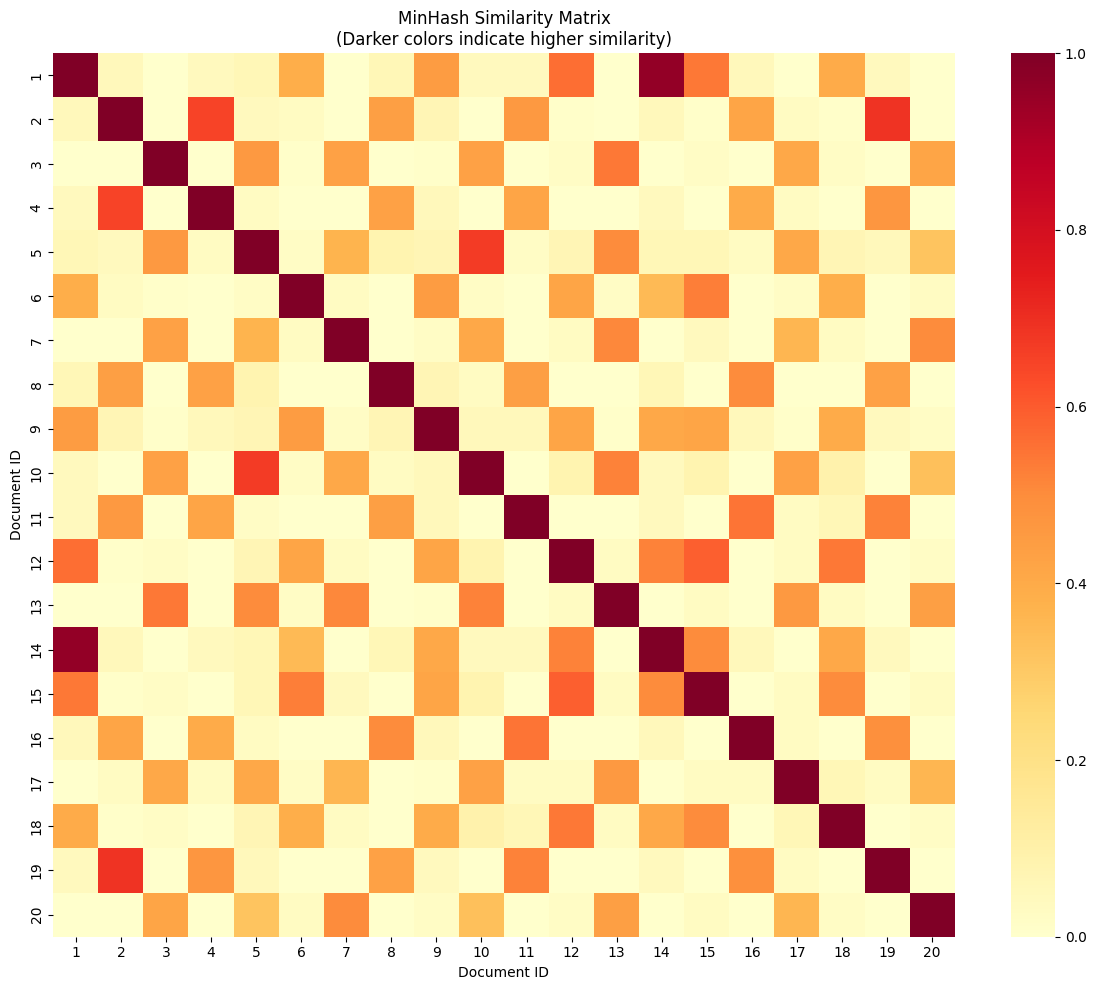

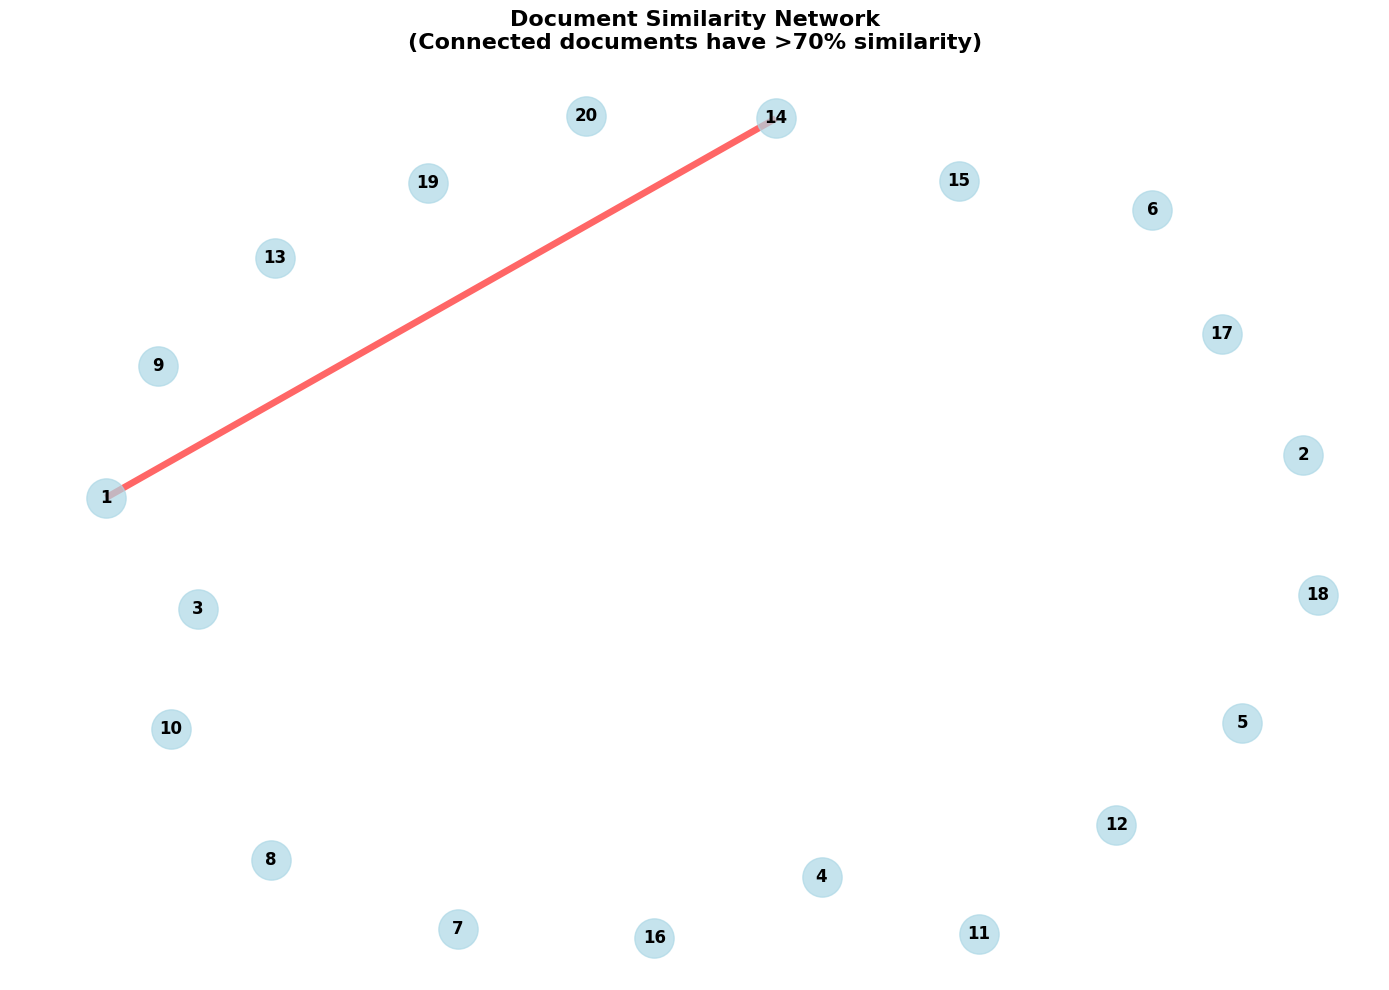


Network Statistics:
Total nodes (documents): 20
Total edges (high similarity pairs): 1
Average similarity of connected pairs: 0.960


In [207]:
# Create similarity heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(minhash_similarity_matrix, 
            annot=False, 
            cmap='YlOrRd', 
            xticklabels=range(1, n_docs+1),
            yticklabels=range(1, n_docs+1))
plt.title('MinHash Similarity Matrix\n(Darker colors indicate higher similarity)')
plt.xlabel('Document ID')
plt.ylabel('Document ID')
plt.tight_layout()
plt.show()

# Create network graph for high similarity connections
G = nx.Graph()

# Add all documents as nodes
for i in range(1, n_docs+1):
    G.add_node(i)

# Add edges for high similarity pairs
for doc1, doc2, mh_sim, _ in high_similarity_pairs:
    G.add_edge(doc1, doc2, weight=mh_sim)

# Draw network graph
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=3, iterations=50)

# Draw nodes
nx.draw_networkx_nodes(G, pos, 
                      node_color='lightblue', 
                      node_size=800,
                      alpha=0.7)

# Draw edges with thickness based on similarity
edges = G.edges(data=True)
for edge in edges:
    weight = edge[2]['weight']
    nx.draw_networkx_edges(G, pos, 
                          edgelist=[(edge[0], edge[1])],
                          width=weight*5,  # Scale edge thickness
                          alpha=0.6,
                          edge_color='red')

nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')

plt.title('Document Similarity Network\n(Connected documents have >70% similarity)', 
          fontsize=16, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"\nNetwork Statistics:")
print(f"Total nodes (documents): {G.number_of_nodes()}")
print(f"Total edges (high similarity pairs): {G.number_of_edges()}")
if G.number_of_edges() > 0:
    avg_similarity = np.mean([data['weight'] for _, _, data in G.edges(data=True)])
    print(f"Average similarity of connected pairs: {avg_similarity:.3f}")

## Analysis and Comparison

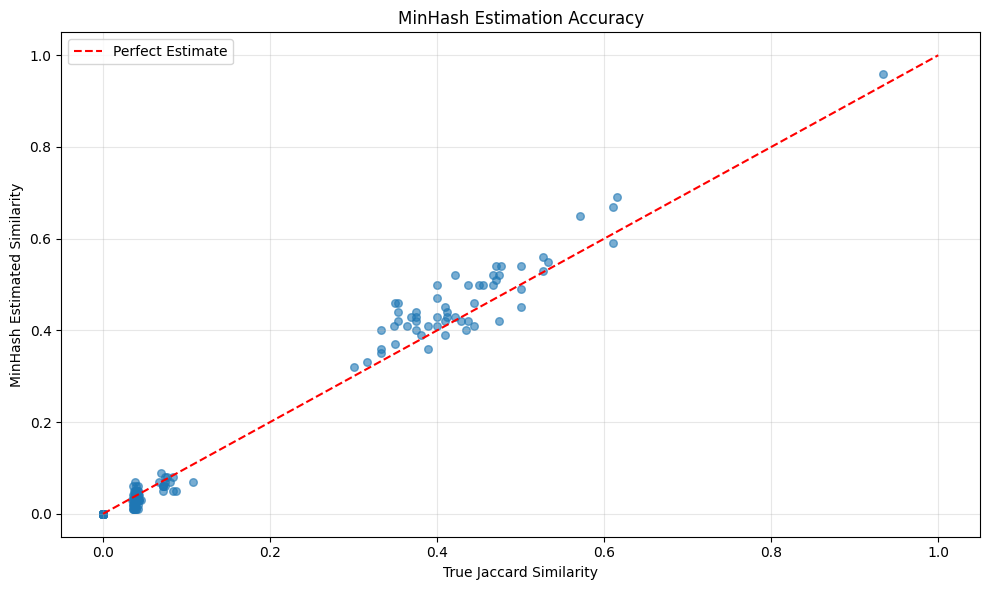


MinHash Estimation Quality:
Mean absolute error: 0.0181
Maximum absolute error: 0.1100
Correlation coefficient: 0.9935

=== SIMILARITY ANALYSIS SUMMARY ===
Total documents analyzed: 20
Hash functions used: 100
Pairs with >70% similarity: 1

Detailed similar pairs:

Documents 1 and 14:
  MinHash similarity: 0.960
  True similarity: 0.933
  Doc 1: NASA plans to build a Mars base by 2040 with ESA through joint space missions....
  Doc 14: NASA plans to build a Mars base by 2040 with ESA through space missions....


In [208]:
plt.figure(figsize=(10, 6))

mask = np.triu(np.ones_like(minhash_similarity_matrix, dtype=bool), k=1)
minhash_values = minhash_similarity_matrix[mask]
true_values = true_similarity_matrix[mask]

plt.scatter(true_values, minhash_values, alpha=0.6, s=30)
plt.plot([0, 1], [0, 1], 'r--', label='Perfect Estimate')
plt.xlabel('True Jaccard Similarity')
plt.ylabel('MinHash Estimated Similarity')
plt.title('MinHash Estimation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

errors = np.abs(minhash_values - true_values)
mean_error = np.mean(errors)
max_error = np.max(errors)

print(f"\nMinHash Estimation Quality:")
print(f"Mean absolute error: {mean_error:.4f}")
print(f"Maximum absolute error: {max_error:.4f}")
print(f"Correlation coefficient: {np.corrcoef(true_values, minhash_values)[0,1]:.4f}")

print(f"\n=== SIMILARITY ANALYSIS SUMMARY ===")
print(f"Total documents analyzed: {n_docs}")
print(f"Hash functions used: {minhash.num_hashes}")
print(f"Pairs with >70% similarity: {len(high_similarity_pairs)}")

if high_similarity_pairs:
    print(f"\nDetailed similar pairs:")
    for doc1, doc2, mh_sim, true_sim in high_similarity_pairs:
        print(f"\nDocuments {doc1} and {doc2}:")
        print(f"  MinHash similarity: {mh_sim:.3f}")
        print(f"  True similarity: {true_sim:.3f}")
        print(f"  Doc {doc1}: {documents[doc1-1][:100]}...")
        print(f"  Doc {doc2}: {documents[doc2-1][:100]}...")
else:
    print("\nNo document pairs found with >70% similarity.")